<a href="https://colab.research.google.com/github/Bisminee/244107020216-mobile-course/blob/main/Pertemuan5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parameter Pribadi Berbasis NIM


|Simbol|Rumus|Rentang|Dipakai Pada|
|------|-----|-------|------------|
|N|tiga digit terakhir|0-999|dasar seluruh parameter|
|bins|2 pangkat ((N mod 4)+3)|8, 16, 32, 64| E-1, jumlah bin histogram|
|clip|1,0+(N mod 5) * 0,5|1,0 - 3,0|E-2, clipLimit CLAHE|
|tile|(N mod 4) + 2|2 - 5|E-2, tileGridSize CLAHE|
|L|2 pangkat ((N mod 3) + 1)|2, 4, 8|E-3, jumlah level kuantisasi



In [2]:
# Sel Identitas - JANGAN DIHAPUS
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Bisma Adhiaksa'
NIM = '244107020216' # ganti dengan NIM Anda
N = int(NIM[-3:])
PARAM = {
'bins' : 2 ** ((N % 4) + 3),
'clip' : round(1.0 + (N % 5) * 0.5, 1),
'tile' : (N % 4) + 2,
'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
  print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Bisma Adhiaksa
NIM : 244107020216 | N = 216
bins   : 8
clip   : 1.5
tile   : 2
L      : 2
WAKTU : 2026-09-24 12:18:17 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 26181377f33bb797


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import skimage as io
import math
import os
import glob

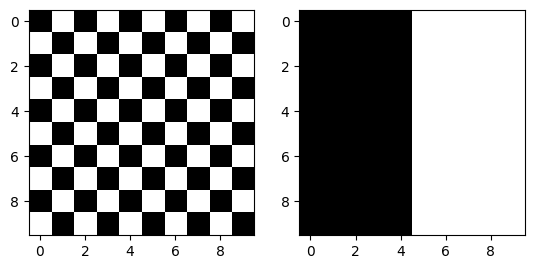

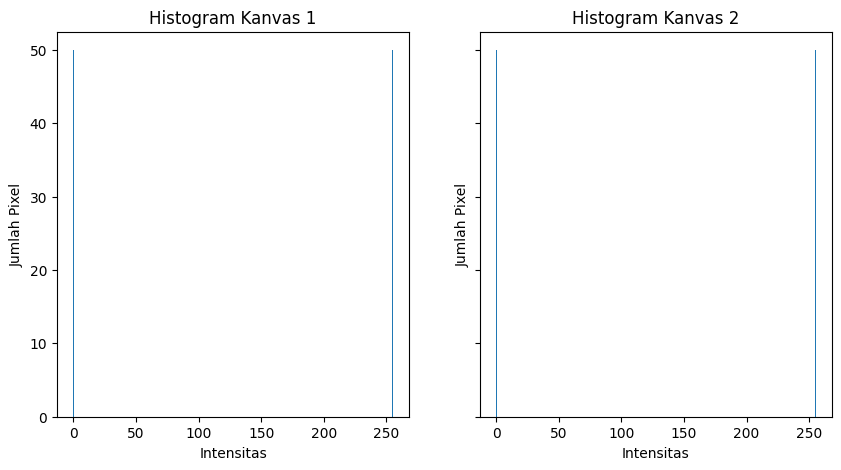

In [120]:
#membuat kanvas pixel 10*10

tinggi_kanvas = 10
lebar_kanvas = 10

kanvas1 = np.zeros((tinggi_kanvas, lebar_kanvas, 3), dtype=np.uint8)
kanvas2 = np.zeros((tinggi_kanvas, lebar_kanvas, 3), dtype=np.uint8)
for y in range(tinggi_kanvas):
  for x in range(lebar_kanvas):
    if (y % 2 == 0 and x % 2 == 0) or (y % 2 == 1 and x % 2 == 1):
      kanvas1[y][x] = 0
    else:
      kanvas1[y][x] = 255
plt.subplot(1, 2, 1)
plt.imshow(kanvas1)

for y in range(tinggi_kanvas):
  for x in range(lebar_kanvas):
    if (x<(lebar_kanvas/2)):
      kanvas2[y][x] = 0
    else:
      kanvas2[y][x] = 255
plt.subplot(1, 2, 2)
plt.imshow(kanvas2)
plt.show()

#histogram kanvas1
hist1 = [0] * 256

for y in range(tinggi_kanvas):
    for x in range(lebar_kanvas):
        nilai = kanvas1[y][x][0]
        hist1[nilai] += 1


#histogram kanvas2
hist2 = [0] * 256

for y in range(tinggi_kanvas):
    for x in range(lebar_kanvas):
        nilai = kanvas2[y][x][0]
        hist2[nilai] += 1


#menampilkan perbandingan histogram
names = np.arange(256)

fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

axs[0].bar(names, hist1)
axs[0].set_title("Histogram Kanvas 1")
axs[0].set_xlabel("Intensitas")
axs[0].set_ylabel("Jumlah Pixel")

axs[1].bar(names, hist2)
axs[1].set_title("Histogram Kanvas 2")
axs[1].set_xlabel("Intensitas")
axs[1].set_ylabel("Jumlah Pixel")

plt.show()

<BarContainer object of 256 artists>

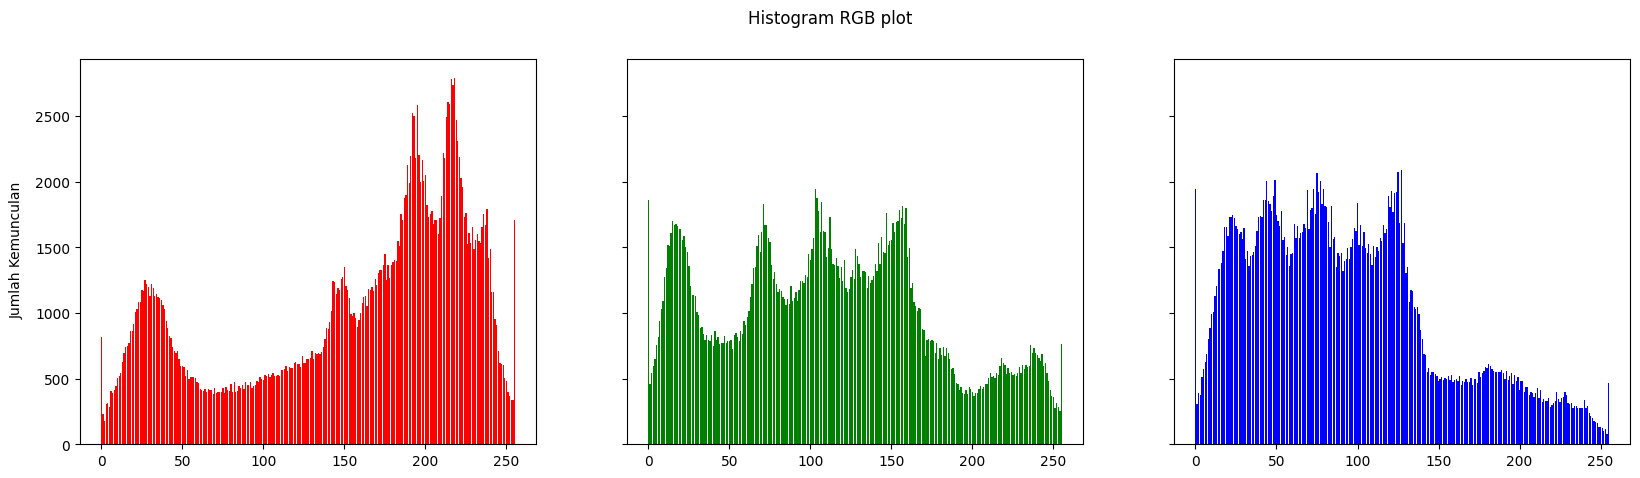

In [7]:
# membuat histogram manual
img = cv.imread('/content/drive/MyDrive/FotoLatihan/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height):
  for x in range(0,width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

<BarContainer object of 256 artists>

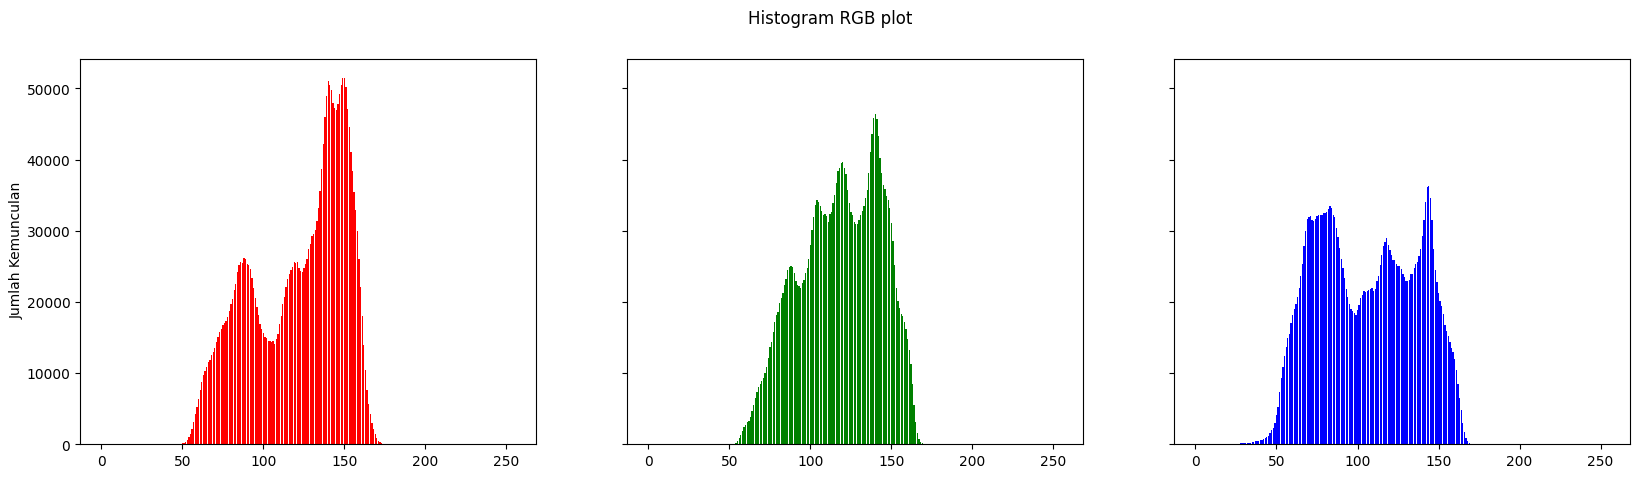

In [9]:
# membuat histogram manual
img = cv.imread('/content/drive/MyDrive/FotoLatihan/KTS1b.jpg.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height):
  for x in range(0,width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

# Pertanyaan Praktikum E1

1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.
2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.
3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.

In [22]:
gambar_coba = cv.imread('/content/drive/MyDrive/FotoLatihan/lena.jpg')
gambar_coba = cv.cvtColor(gambar_coba, cv.COLOR_BGR2RGB)

r, g, b = cv.split(gambar_coba)
